Connected to base (Python 3.11.4)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymrio
os.chdir('/Users/huangjinyang/Documents/NYUAD/Fall 24/Capstone')

In [ ]:
current_directory = os.getcwd()
print("Current Directory:", current_directory)

Current Directory: /Users/huangjinyang/Documents/NYUAD/Fall 24/Capstone


In [ ]:
exio2021p = pymrio.parse_exiobase3(path="/Users/huangjinyang/Documents/NYUAD/Fall 24/Capstone/data/EXIO3/IOT_2021_pxp.zip")
exio2021p.calc_all()

In [ ]:
exio2021p.get_regions()
all_country = ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GR',
       'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO',
       'SE', 'SI', 'SK', 'GB', 'US', 'JP', 'CN', 'CA', 'KR', 'BR', 'IN', 'MX',
       'RU', 'AU', 'CH', 'TR', 'TW', 'NO', 'ID', 'ZA', 'WA', 'WL', 'WE', 'WF',
       'WM']

In [ ]:
Z_p = exio2021p.Z
Y_p = exio2021p.Y
A_p = exio2021p.A
L_p = exio2021p.L

In [ ]:
product = [
    "Leather and leather products (19)",
    "Motor Gasoline",
    "Aviation Gasoline",
    "Gasoline Type Jet Fuel",
    "Kerosene Type Jet Fuel",
    "Kerosene",
    "Gas/Diesel Oil",
    "Heavy Fuel Oil",
    "Refinery Gas",
    "Liquefied Petroleum Gases (LPG)",
    "Refinery Feedstocks",
    "Non-specified Petroleum Products",
    "Chemicals nec",
    "Biodiesels",
    "Other Liquid Biofuels",
    "Additives/Blending Components",
    "Fabricated metal products, except machinery and equipment (28)",
    "Machinery and equipment n.e.c. (29)",
    "Copper products",
    "Basic iron and steel and of ferro-alloys and first products thereof",
    "Medical, precision and optical instruments, watches and clocks (33)",
    "Electrical machinery and apparatus n.e.c. (31)",
    "Office machinery and computers (30)",
    "Radio, television and communication equipment and apparatus (32)",
    "Motor vehicles, trailers and semi-trailers (34)",
    "Other transport equipment (35)",
    "Furniture; other manufactured goods n.e.c. (36)"
]

In [ ]:
filtered_columns = [(region, sector) for region, sector in L_p.columns if region == 'RU' and sector in product]
# Create a new DataFrame with the filtered columns
filtered_L_p = L_p.loc[:, filtered_columns]

In [ ]:
indices_list = []
for column in filtered_L_p.columns:
    # Sort the column in descending order and get the indices
    sorted_indices = filtered_L_p[column].sort_values(ascending=False).index.tolist()
    # Append the list of indices to the nested list
    indices_list.append(sorted_indices)

In [ ]:
# Initialize a new list to store the filtered results
filtered_indices_list = []

# Loop through each sublist in indices_list
for sublist in indices_list:
    # Filter out tuples where the 'region' is 'RU'
    filtered_sublist = [index for index in sublist if index[0] != 'RU']
    # Append the filtered sublist to the new nested list
    filtered_indices_list.append(filtered_sublist)

In [ ]:
# Define the list of EU country codes
ex_countries = [
    'AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 
    'FR', 'GR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 
    'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK', 'GB', 'US',
    'AU', 'CA', 'NO'
] # 32 countries

In [ ]:
Z_tot = Z_p.copy()
# Filter rows where the region is in ex_countries and sector is in product
row_indices = [(region, sector) for region, sector in Z_p.index if region != 'RU' and sector in product]

# Filter columns where the region is 'RU'
column_indices = [(region, sector) for region, sector in Z_p.columns if region == 'RU']

# Set the selected entries to zero
for row in row_indices:
    for col in column_indices:
        Z_tot.at[row, col] = 0

# Compute the sanctions impact from all countries
IO_tot = pymrio.IOSystem()
IO_tot.Z = Z_tot
IO_tot.Y = Y_p
F=exio2021p.factor_inputs.F
factor_input = pymrio.Extension(
    name="Factor Input",
    F=F
)
IO_tot.factor_inputs = factor_input
IO_tot.factor_inputs.unit = exio2021p.factor_inputs.unit
IO_tot.calc_all()

#  Ranking 
L_tot= IO_tot.L
filtered_L_tot = L_tot.loc[:, filtered_columns]

indices_list_tot = []
for column in filtered_L_tot.columns:
    # Sort the column in descending order and get the indices
    sorted_indices = filtered_L_tot[column].sort_values(ascending=False).index.tolist()
    # Append the list of indices to the nested list
    indices_list_tot.append(sorted_indices)

# Reaction from Russian production 
fd_ru = Y_p.loc[:, (['RU'], slice(None))]
fd_ru['FD'] = fd_ru.sum(axis=1)
FD_RU = fd_ru['FD']
x_RU=L_p.dot(FD_RU)
x_tot_RU = L_tot.dot(FD_RU)
tot_reduc = 1 - x_tot_RU / x_RU
tot_reduc_RU = tot_reduc[tot_reduc.index.get_level_values(0) == 'RU']
tot_reduc_RU = tot_reduc_RU.sort_values(ascending=False)

<ipython-input-11-a5a116b66c59>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fd_ru['FD'] = fd_ru.sum(axis=1)


In [ ]:
#sum(x_tot_RU[x_tot_RU.index.get_level_values(0) == 'RU']) - sum(x_RU[x_RU.index.get_level_values(0) == 'RU']) # -103881.83 M. Euro
sum(x_tot_RU) / sum(x_RU) - 1 # -0.0412 

-0.041269646093454626

In [ ]:
Z_imp = Z_p.copy()
# Filter rows where the region is in ex_countries and sector is in product
row_indices = [(region, sector) for region, sector in Z_p.index if region in ex_countries and sector in product]

# Filter columns where the region is 'RU'
column_indices = [(region, sector) for region, sector in Z_p.columns if region == 'RU']

# Set the selected entries to zero
for row in row_indices:
    for col in column_indices:
        Z_imp.at[row, col] = 0

# Compute the sanctions impact from EU+ countries
IO_imp = pymrio.IOSystem()
IO_imp.Z = Z_imp
IO_imp.Y = Y_p
F=exio2021p.factor_inputs.F
factor_input = pymrio.Extension(
    name="Factor Input",
    F=F
)
IO_imp.factor_inputs = factor_input
IO_imp.factor_inputs.unit = exio2021p.factor_inputs.unit
IO_imp.calc_all()

#  Ranking 
L_imp= IO_imp.L
filtered_L_imp = L_imp.loc[:, filtered_columns]

indices_list_imp = []
for column in filtered_L_imp.columns:
    # Sort the column in descending order and get the indices
    sorted_indices = filtered_L_imp[column].sort_values(ascending=False).index.tolist()
    # Append the list of indices to the nested list
    indices_list_imp.append(sorted_indices)

# Reaction from Russian production 
fd_ru = Y_p.loc[:, (['RU'], slice(None))]
fd_ru['FD'] = fd_ru.sum(axis=1)
FD_RU = fd_ru['FD']
x_RU=L_p.dot(FD_RU)
x_imp_RU = L_imp.dot(FD_RU)
output27_ratio = 1 - x_imp_RU / x_RU
ratio_RU = output27_ratio[output27_ratio.index.get_level_values(0) == 'RU']
ratio_RU = ratio_RU.sort_values(ascending=False)

<ipython-input-13-2f0c6a070fa9>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fd_ru['FD'] = fd_ru.sum(axis=1)


In [ ]:
tot_reduc_RU = pd.concat([ratio_RU, tot_reduc_RU], axis=1, join="outer")
tot_reduc_RU.columns = ["reduction_EU+", "reduction_tot"]
tot_reduc_RU["ratio"] = tot_reduc_RU["reduction_EU+"] / tot_reduc_RU["reduction_tot"]
tot_reduc_RU["reduction_third"] = tot_reduc_RU["reduction_tot"] -tot_reduc_RU["reduction_EU+"]

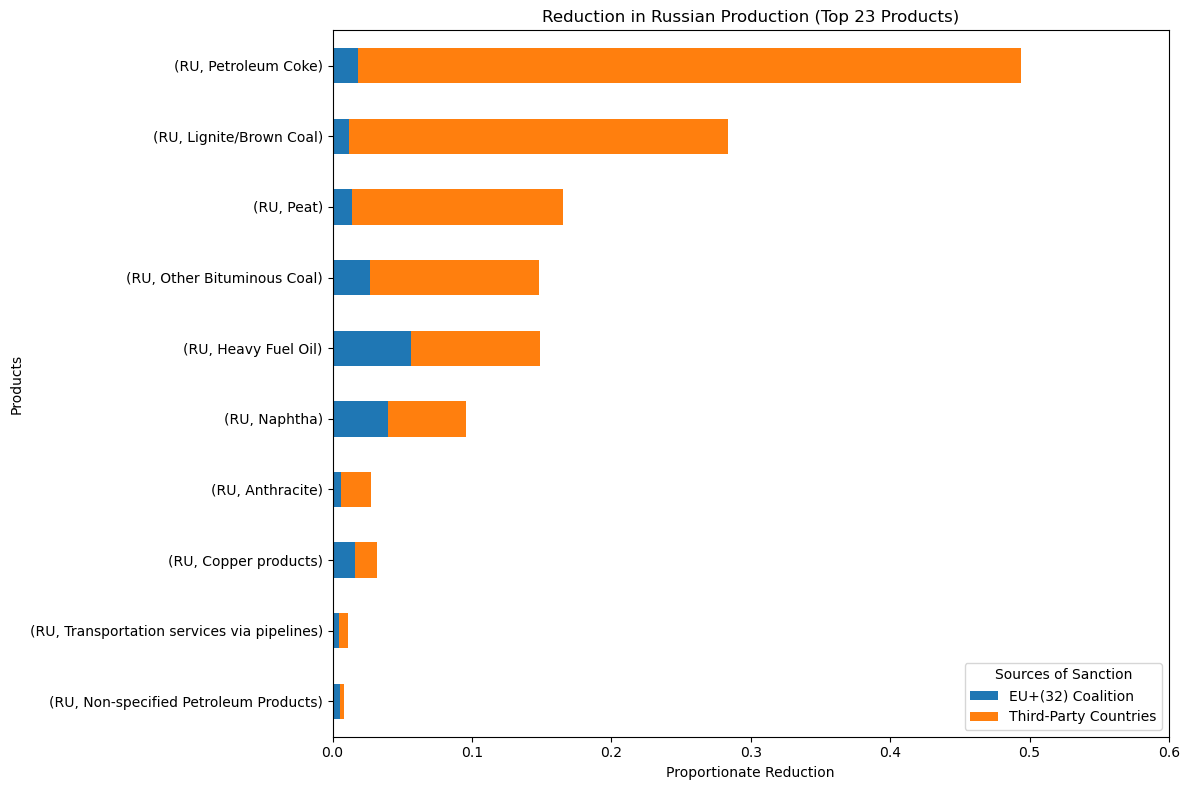

In [ ]:
filtered_ratio_RU =  tot_reduc_RU[ tot_reduc_RU['reduction_EU+'] > 0.004 ] #Top 10
#filtered_ratio_RU =  tot_reduc_RU[(tot_reduc_RU['reduction_EU+'] < 0.004) & (tot_reduc_RU['reduction_EU+'] > 0.001)] #Top 20
sorted_df = filtered_ratio_RU.sort_values(by="reduction_third", ascending=True)

# Create a stacked bar plot for the selected columns
plt.figure(figsize=(12, 8))
# Create a horizontal (barh) stacked bar plot
ax = sorted_df[['reduction_EU+', 'reduction_third']].plot(kind='barh', stacked=True, ax=plt.gca())

# Customize the labels and title
ax.set_xlabel("Proportionate Reduction")
ax.set_ylabel("Products")
ax.set_title("Reduction in Russian Production (Top 23 Products)")
#ax.set_title("Reduction in Russian Production (Top 11-20 Products)")
ax.set_xlim(0,0.6)

# Set custom legend labels and title
ax.legend(
    ["EU+(32) Coalition", "Third-Party Countries"],
    title="Sources of Sanction",
    loc='best'
)

plt.tight_layout()
plt.show()

In [ ]:
third_party = list(set(all_country) - set(ex_countries) - set(['RU']))
ratio_dict = {}
ratio_RU_dict = {}
for country in third_party:
    Z_temp = Z_p.copy()
    row_indices = [(region, sector) for region, sector in Z_p.index if region == country and sector in product]
    column_indices = [(region, sector) for region, sector in Z_p.columns if region == 'RU']
    for row in row_indices:
        for col in column_indices:
            Z_temp.at[row, col] = 0
    IO_temp = pymrio.IOSystem()
    IO_temp.Z = Z_temp
    IO_temp.Y = Y_p
    F=exio2021p.factor_inputs.F
    factor_input = pymrio.Extension(
    name="Factor Input",
    F=F
    )
    IO_temp.factor_inputs = factor_input
    IO_temp.factor_inputs.unit = exio2021p.factor_inputs.unit
    IO_temp.calc_all()
    fd_ru_temp = Y_p.loc[:, (['RU'], slice(None))]
    fd_ru_temp['FD'] = fd_ru_temp.sum(axis=1)
    FD_RU_temp = fd_ru_temp['FD']
    x_RU_temp=L_p.dot(FD_RU)
    x_imp_RU_temp = IO_temp.L.dot(FD_RU)
    ratio_temp = 1-x_imp_RU_temp / x_RU_temp
    ratio_dict[country] = ratio_temp
    ratio_RU_dict[country] = ratio_temp[ratio_temp.index.get_level_values(0) == 'RU'].sort_values(ascending=False)
# To dataframe
ratio_ex2 = pd.DataFrame(ratio_dict)   
ratio_ex2['reduction_third'] = ratio_ex2.sum(axis=1)

<ipython-input-25-ebc79ed559d9>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fd_ru_temp['FD'] = fd_ru_temp.sum(axis=1)
<ipython-input-25-ebc79ed559d9>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fd_ru_temp['FD'] = fd_ru_temp.sum(axis=1)
<ipython-input-25-ebc79ed559d9>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

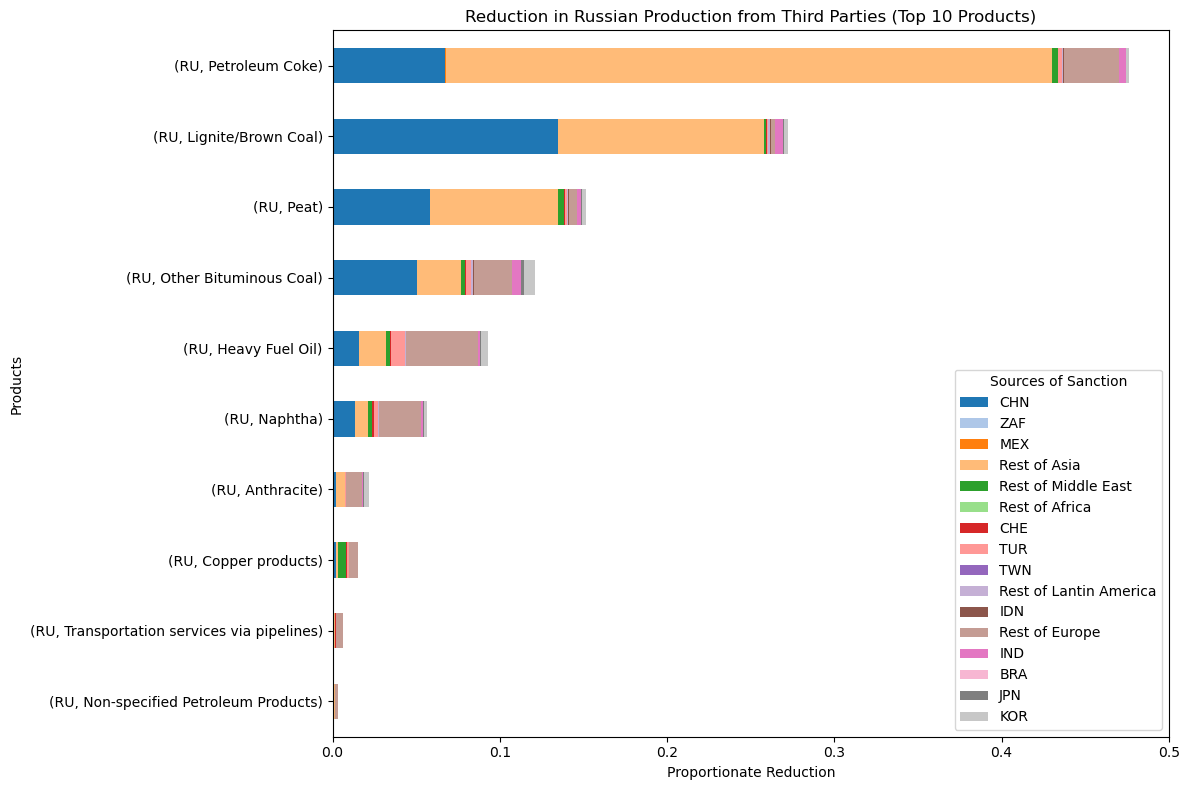

In [ ]:
ratio_ex2_RU= ratio_ex2[ratio_ex2.index.get_level_values(0)=='RU']

order = ['CN','ZA','MX','WA','WM','WF','CH','TR','TW','WL','ID','WE','IN','BR','JP','KR']

ratio_ex2_RU = ratio_ex2_RU.reindex(columns=order)
# or keep existing others after the ordered ones:
ratio_ex2_RU = ratio_ex2_RU.reindex(columns=order + [c for c in ratio_ex2_RU.columns if c not in order])


filtered_data = ratio_ex2_RU[ratio_ex2_RU.index.get_level_values(1).isin(sorted_df.index.get_level_values(1))]
filtered_data = filtered_data.reindex(sorted_df.index)

# Generate a set of 16 distinct colors using a colormap.
# Here we use the 'tab20' colormap and select the first 16 colors.
colors = plt.cm.tab20.colors[:16]

# Create a new figure and axis with a specified size.
fig, ax = plt.subplots(figsize=(12, 8))

# Plot a horizontal stacked bar chart using the distinct colors.
# Note: Passing the 'color' argument ensures each column gets its designated color.
filtered_data.plot(kind='barh', stacked=True, ax=ax, color=colors)

# Customize the axis labels and title.
ax.set_xlabel("Proportionate Reduction")
ax.set_ylabel("Products")
ax.set_title("Reduction in Russian Production from Third Parties (Top 10 Products)")

# Customize the legend: 
# Here we assume that the columns of filtered_data are named after the countries.
# We set the legend labels to the desired custom names.
custom_labels = [
    'CHN',"ZAF",'MEX','Rest of Asia','Rest of Middle East','Rest of Africa','CHE',
    'TUR','TWN','Rest of Lantin America','IDN','Rest of Europe','IND','BRA','JPN','KOR'
]

# If you want to use the existing column names as the legend labels but with custom title,
# you can simply do this:
#ax.legend(filtered_data.columns, title="Sources of Sanction", loc='best')

# Alternatively, if you have a custom list of labels for each country, you can pass that list:
ax.legend(custom_labels, title="Sources of Sanction", loc='best')

# Adjust the layout and show the plot.
plt.tight_layout()
plt.show()

In [ ]:
ratio_ex2['reduction_third'] = ratio_ex2.sum(axis=1)
gap = tot_reduc_RU['reduction_third']-ratio_ex2['reduction_third']
gap.mean() # -8.633414557485652e-06
gap.std() # 6.0746932473528674e-05

6.0746932473528674e-05

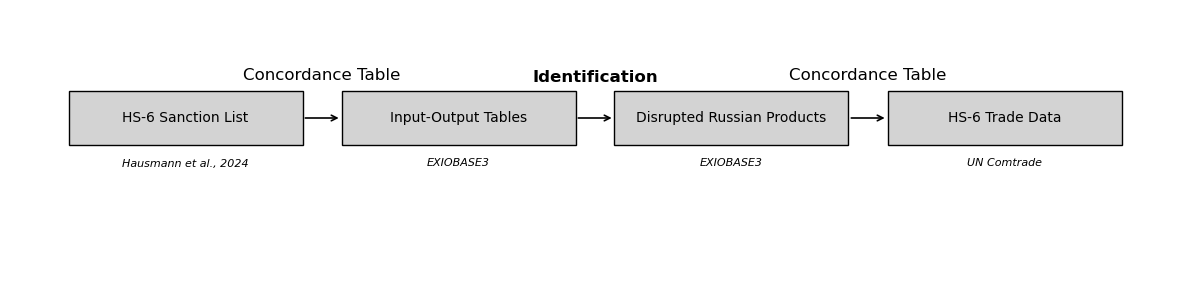

In [ ]:
from matplotlib.patches import Rectangle

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')

# Box parameters
box_width = 0.2
box_height = 0.2
y = 0.5  # vertical position of boxes

# Labels and subtexts
labels = ["HS-6 Sanction List", "Input-Output Tables", "Disrupted Russian Products", "HS-6 Trade Data"]
subtexts = ["Hausmann et al., 2024", "EXIOBASE3", "EXIOBASE3", "UN Comtrade"]

# Evenly spaced x positions for boxes
x_positions = np.linspace(0.05, 0.75, len(labels))

# Draw boxes with labels and subtexts
for x, label, sub in zip(x_positions, labels, subtexts):
    rect = Rectangle((x, y), box_width, box_height, linewidth=1, edgecolor='black', facecolor='lightgrey')
    ax.add_patch(rect)
    ax.text(x + box_width / 2, y + box_height / 2, label, ha='center', va='center', fontsize=10)
    ax.text(x + box_width / 2, y - 0.05, sub, ha='center', va='top', fontsize=8, style='italic')

# Draw arrows and annotate "Concordance Table"
for i in range(len(labels) - 1):
    x_start = x_positions[i] + box_width
    x_end = x_positions[i + 1]
    y_mid = y + box_height / 2
    ax.annotate('', xy=(x_end, y_mid), xytext=(x_start, y_mid),
                arrowprops=dict(arrowstyle='->', lw=1.2))
    # Only above the first and third arrows
    if i in (0, 2):
        ax.text((x_start + x_end) / 2, y_mid + 0.13, "Concordance Table",
                ha='center', va='bottom', fontsize=12)

# Add top title
ax.text(0.5, 0.75, "Identification", ha='center', va='center',
        fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()